# Text Classification and Sentiment Analysis Using NLP

## Loading Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

## NLP Text Preprocessing

### Load Dataset

In [4]:
df = pd.read_csv("amazonreviews.tsv", sep="\t")
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


### Basic Info

In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   10000 non-null  str  
 1   review  10000 non-null  str  
dtypes: str(2)
memory usage: 156.4 KB


,label,review
count,10000,10000
unique,2,10000
top,neg,Stuning even for the non-gamer: This sound tra...
freq,5097,1


### Handling Missing Reviews

In [6]:
df.dropna(subset=["review"], inplace=True)

### Removing Duplicate Reviews

In [7]:
df.drop_duplicates(subset=["review"], inplace=True)

### Converting Text to Lowercase

In [8]:
df["review"] = df["review"].str.lower()

### Removing Punctuation and Special Characters

In [9]:
df["review"] = df["review"].apply(
    lambda x: re.sub(r"[^a-z\s]", "", x)
)

## Exploratory Data Analysis

### Distribution of Positive vs Negative Reviews

In [10]:
sentiment_counts = df["label"].value_counts()
sentiment_counts

label
neg    5097
pos    4903
Name: count, dtype: int64

### Plot sentiment distribution

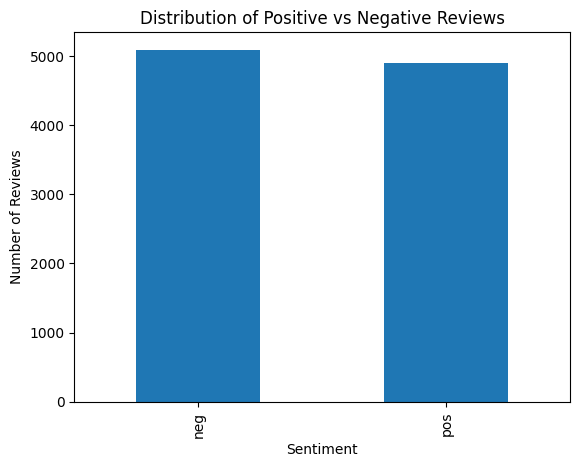

In [11]:
sentiment_counts.plot(kind="bar")
plt.title("Distribution of Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

### Separate Positive and Negative Reviews

In [12]:
positive_reviews = df[df["label"] == "pos"]["review"]
negative_reviews = df[df["label"] == "neg"]["review"]

### Frequently Used Words in Positive Reviews

In [13]:
pos_words = " ".join(positive_reviews).split()
pos_words = [w for w in pos_words if w not in ENGLISH_STOP_WORDS]
Counter(pos_words).most_common(10)

[('book', 3313),
 ('great', 2087),
 ('good', 1635),
 ('read', 1553),
 ('like', 1268),
 ('movie', 1085),
 ('just', 1022),
 ('love', 902),
 ('time', 871),
 ('really', 827)]

### Frequently Used Words in Negative Reviews

In [14]:
neg_words = " ".join(negative_reviews).split()
neg_words = [w for w in neg_words if w not in ENGLISH_STOP_WORDS]
Counter(neg_words).most_common(10)

[('book', 3184),
 ('like', 1547),
 ('just', 1507),
 ('movie', 1465),
 ('dont', 1240),
 ('read', 1187),
 ('good', 1134),
 ('time', 1034),
 ('buy', 814),
 ('really', 778)]

### Word Clouds for Positive Reviews

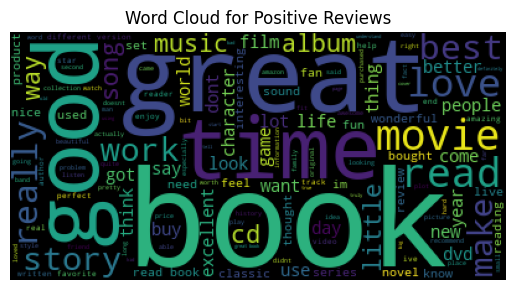

In [15]:
pos_text = " ".join(pos_words)

WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(pos_text)

plt.imshow(WordCloud().generate(pos_text))
plt.axis("off")
plt.title("Word Cloud for Positive Reviews")
plt.show()

### Word Cloud for Negative Reviews

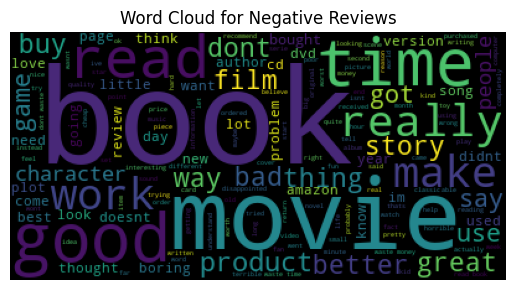

In [16]:
neg_text = " ".join(neg_words)

plt.imshow(WordCloud().generate(neg_text))
plt.axis("off")
plt.title("Word Cloud for Negative Reviews")
plt.show()

### Sentiment Analysis Insights

* The exploratory analysis shows that several frequently occurring words appear in both positive and negative reviews. This overlap is expected, as customers discuss the same products regardless of sentiment. Words such as *book*, *movie*, and *read* represent product-related topics rather than sentiment polarity.

* Word clouds are based on raw word frequency and therefore highlight common discussion themes instead of emotional tone. Sentiment differentiation is captured later using TF-IDF feature extraction and classification models, which consider word importance and context rather than simple frequency.


## Feature Extraction

### TF-IDF feature extraction

In [17]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["review"])
y = df["label"]

### Train–Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Development


In [19]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Model Evaluation

In [20]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.843
              precision    recall  f1-score   support

         neg       0.85      0.84      0.85      1037
         pos       0.83      0.84      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



* The performance of the sentiment classification model was evaluated using accuracy, precision, recall, and F1-score. The Logistic Regression classifier achieved an accuracy of approximately 84%, indicating strong predictive performance on unseen test data.

* Both positive and negative classes show balanced precision and recall values, suggesting that the model does not favor one class over the other. The F1-score further confirms the robustness of the model by balancing precision and recall, making it a suitable metric for sentiment analysis tasks.

### Cross-Validation 

In [21]:
cv_f1_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("Cross-Validation F1 Scores:", cv_f1_scores)
print("Mean CV F1-Score:", cv_f1_scores.mean())

Cross-Validation F1 Scores: [0.85300882 0.83100811 0.8294     0.83101538 0.84651347]
Mean CV F1-Score: 0.8381891582920599


## BERT Sentiment Classification

### Import BERT Libraries

In [22]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset

c:\Users\graj2\Data Science\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Encode Labels

In [23]:
# Convert labels to numeric (neg=0, pos=1)
label_encoder = LabelEncoder()
df["encoded_label"] = label_encoder.fit_transform(df["label"])

### Train-Test Split (For BERT)

In [24]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["review"],
    df["encoded_label"],
    test_size=0.2,
    random_state=42
)

### Load Tokenizer

In [25]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

### Create Dataset Class

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

In [27]:
from transformers import logging
logging.set_verbosity_error()

### Load Pretrained BERT Model

In [28]:
model_bert = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 562.04it/s, Materializing param=bert.pooler.dense.weight]                               


### Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,                 # reduce epochs
    per_device_train_batch_size=8,      # smaller batch
    per_device_eval_batch_size=8,
    logging_dir="./logs",
    save_strategy="no",
    dataloader_pin_memory=False,        # remove warning
    logging_steps=50                    # show progress faster
)

### Trainer Setup

In [30]:
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

### Train BERT

In [31]:
trainer.train()

{'loss': '0.5723', 'grad_norm': '3.526', 'learning_rate': '4.755e-05', 'epoch': '0.05'}
{'loss': '0.3378', 'grad_norm': '3.959', 'learning_rate': '4.505e-05', 'epoch': '0.1'}
{'loss': '0.3778', 'grad_norm': '5.54', 'learning_rate': '4.255e-05', 'epoch': '0.15'}
{'loss': '0.3811', 'grad_norm': '32.62', 'learning_rate': '4.005e-05', 'epoch': '0.2'}
{'loss': '0.3092', 'grad_norm': '48.21', 'learning_rate': '3.755e-05', 'epoch': '0.25'}
{'loss': '0.3255', 'grad_norm': '7.863', 'learning_rate': '3.505e-05', 'epoch': '0.3'}
{'loss': '0.2285', 'grad_norm': '4.694', 'learning_rate': '3.255e-05', 'epoch': '0.35'}
{'loss': '0.3644', 'grad_norm': '1.033', 'learning_rate': '3.005e-05', 'epoch': '0.4'}
{'loss': '0.2811', 'grad_norm': '8.399', 'learning_rate': '2.755e-05', 'epoch': '0.45'}
{'loss': '0.2565', 'grad_norm': '0.6346', 'learning_rate': '2.505e-05', 'epoch': '0.5'}
{'loss': '0.3658', 'grad_norm': '0.7551', 'learning_rate': '2.255e-05', 'epoch': '0.55'}
{'loss': '0.2062', 'grad_norm': '0.1

TrainOutput(global_step=1000, training_loss=0.30628759717941284, metrics={'train_runtime': 382.2959, 'train_samples_per_second': 20.926, 'train_steps_per_second': 2.616, 'train_loss': 0.30628759717941284, 'epoch': 1.0})

### Evaluate BERT

In [32]:
from sklearn.metrics import accuracy_score, f1_score

predictions = trainer.predict(test_dataset)
pred_labels = predictions.predictions.argmax(-1)

bert_accuracy = accuracy_score(test_labels, pred_labels)
bert_f1 = f1_score(test_labels, pred_labels)

print("BERT Accuracy:", bert_accuracy)
print("BERT F1 Score:", bert_f1)

BERT Accuracy: 0.927
BERT F1 Score: 0.9236401673640168


### Model Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "BERT"],
    "Accuracy": [accuracy, bert_accuracy],
    "F1 Score": [cv_f1_scores.mean(), bert_f1]
})
comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.843,0.838189
1,BERT,0.927,0.923640


### Model Comparison and Performance Analysis
"""
A comparative evaluation was conducted between a traditional
machine learning model (Logistic Regression with TF-IDF features)
and a transformer-based deep learning model (BERT).

Logistic Regression achieved an accuracy of 84.3% and an
F1-score of 83.8%, providing a strong baseline for sentiment
classification.

After fine-tuning, the BERT model achieved an accuracy of 92.7%
and an F1-score of 92.4%, indicating a substantial improvement
in predictive performance.

The results show that contextual language models significantly
enhance classification capability, particularly in handling
complex sentence structures, negations, and nuanced expressions.

This comparison validates the effectiveness of transformer-based
architectures for large-scale sentiment analysis tasks.
"""

## Conclusion

* This project successfully developed an automated sentiment analysis system capable of classifying Amazon product reviews as positive or negative using advanced NLP techniques.

* The workflow combined structured preprocessing, exploratory text analysis, traditional machine learning models, and state-of-the-art transformer-based deep learning models.

* The implementation demonstrates how sentiment analysis systems can scale to thousands of reviews and provide actionable insights for real-time product monitoring.

* By identifying shifts in customer sentiment, businesses can proactively address product issues, improve service quality, and enhance overall customer satisfaction.

* The integration of transformer-based models further strengthens the system’s ability to understand contextual meaning, making it highly suitable for deployment in real-world e-commerce environments.